In [1]:
!pip install ucimlrepo xgboost shap optuna gradio langchain-community chromadb sentence-transformers -q

  You can safely remove it manually.


In [4]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [7]:
!pip install kagglehub

  Using cached kagglehub-1.0.2-py3-none-any.whl.metadata (40 kB)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

In [10]:
import os
import kagglehub
# Set the kagglehub download cache directory to your chosen folder
os.environ["KAGGLEHUB_CACHE_DIR"] = os.path.normpath("../dataset/")

# Download the dataset into that specified directory
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

# Read the CSV from the dynamically returned download path
df = pd.read_csv(f"{path}/heart.csv")

X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease'].values  # already binary, no transform needed

# encode categorical columns
X = pd.get_dummies(X, columns=['Sex', 'ChestPainType', 'RestingECG',
                               'ExerciseAngina', 'ST_Slope'])
X = X.astype(float)

print("Shape:", X.shape)
print("Disease:", y.sum(), "| Healthy:", (y==0).sum())
X.head()

100%|██████████| 8.56k/8.56k [00:00<00:00, 6.49MB/s]

Extracting files...
Shape: (918, 20)
Disease: 508 | Healthy: 410


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40.0,140.0,289.0,0.0,172.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,49.0,160.0,180.0,0.0,156.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,37.0,130.0,283.0,0.0,98.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
3,48.0,138.0,214.0,0.0,108.0,1.5,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,54.0,150.0,195.0,0.0,122.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


In [11]:
X

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40.0,140.0,289.0,0.0,172.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,49.0,160.0,180.0,0.0,156.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,37.0,130.0,283.0,0.0,98.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
3,48.0,138.0,214.0,0.0,108.0,1.5,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,54.0,150.0,195.0,0.0,122.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45.0,110.0,264.0,0.0,132.0,1.2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
914,68.0,144.0,193.0,1.0,141.0,3.4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
915,57.0,130.0,131.0,0.0,115.0,1.2,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
916,57.0,130.0,236.0,0.0,174.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [12]:
y

array([0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,

In [13]:
y = df['HeartDisease'].values

print("Class distribution:")
import numpy as np
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    label = {0:'healthy', 1:'disease'}[u]
    print(f"  {u} ({label}): {c} patients")

Class distribution:
  0 (healthy): 410 patients
  1 (disease): 508 patients


In [14]:
print("Missing values per column:")
print(X.isnull().sum())
print("\nTotal missing:", X.isnull().sum().sum())
# this dataset is cleaner than UCI, likely zero missing values
# XGBoost handles any remaining nulls natively anyway

Missing values per column:
Age                  0
RestingBP            0
Cholesterol          0
FastingBS            0
MaxHR                0
Oldpeak              0
Sex_F                0
Sex_M                0
ChestPainType_ASY    0
ChestPainType_ATA    0
ChestPainType_NAP    0
ChestPainType_TA     0
RestingECG_LVH       0
RestingECG_Normal    0
RestingECG_ST        0
ExerciseAngina_N     0
ExerciseAngina_Y     0
ST_Slope_Down        0
ST_Slope_Flat        0
ST_Slope_Up          0
dtype: int64

Total missing: 0


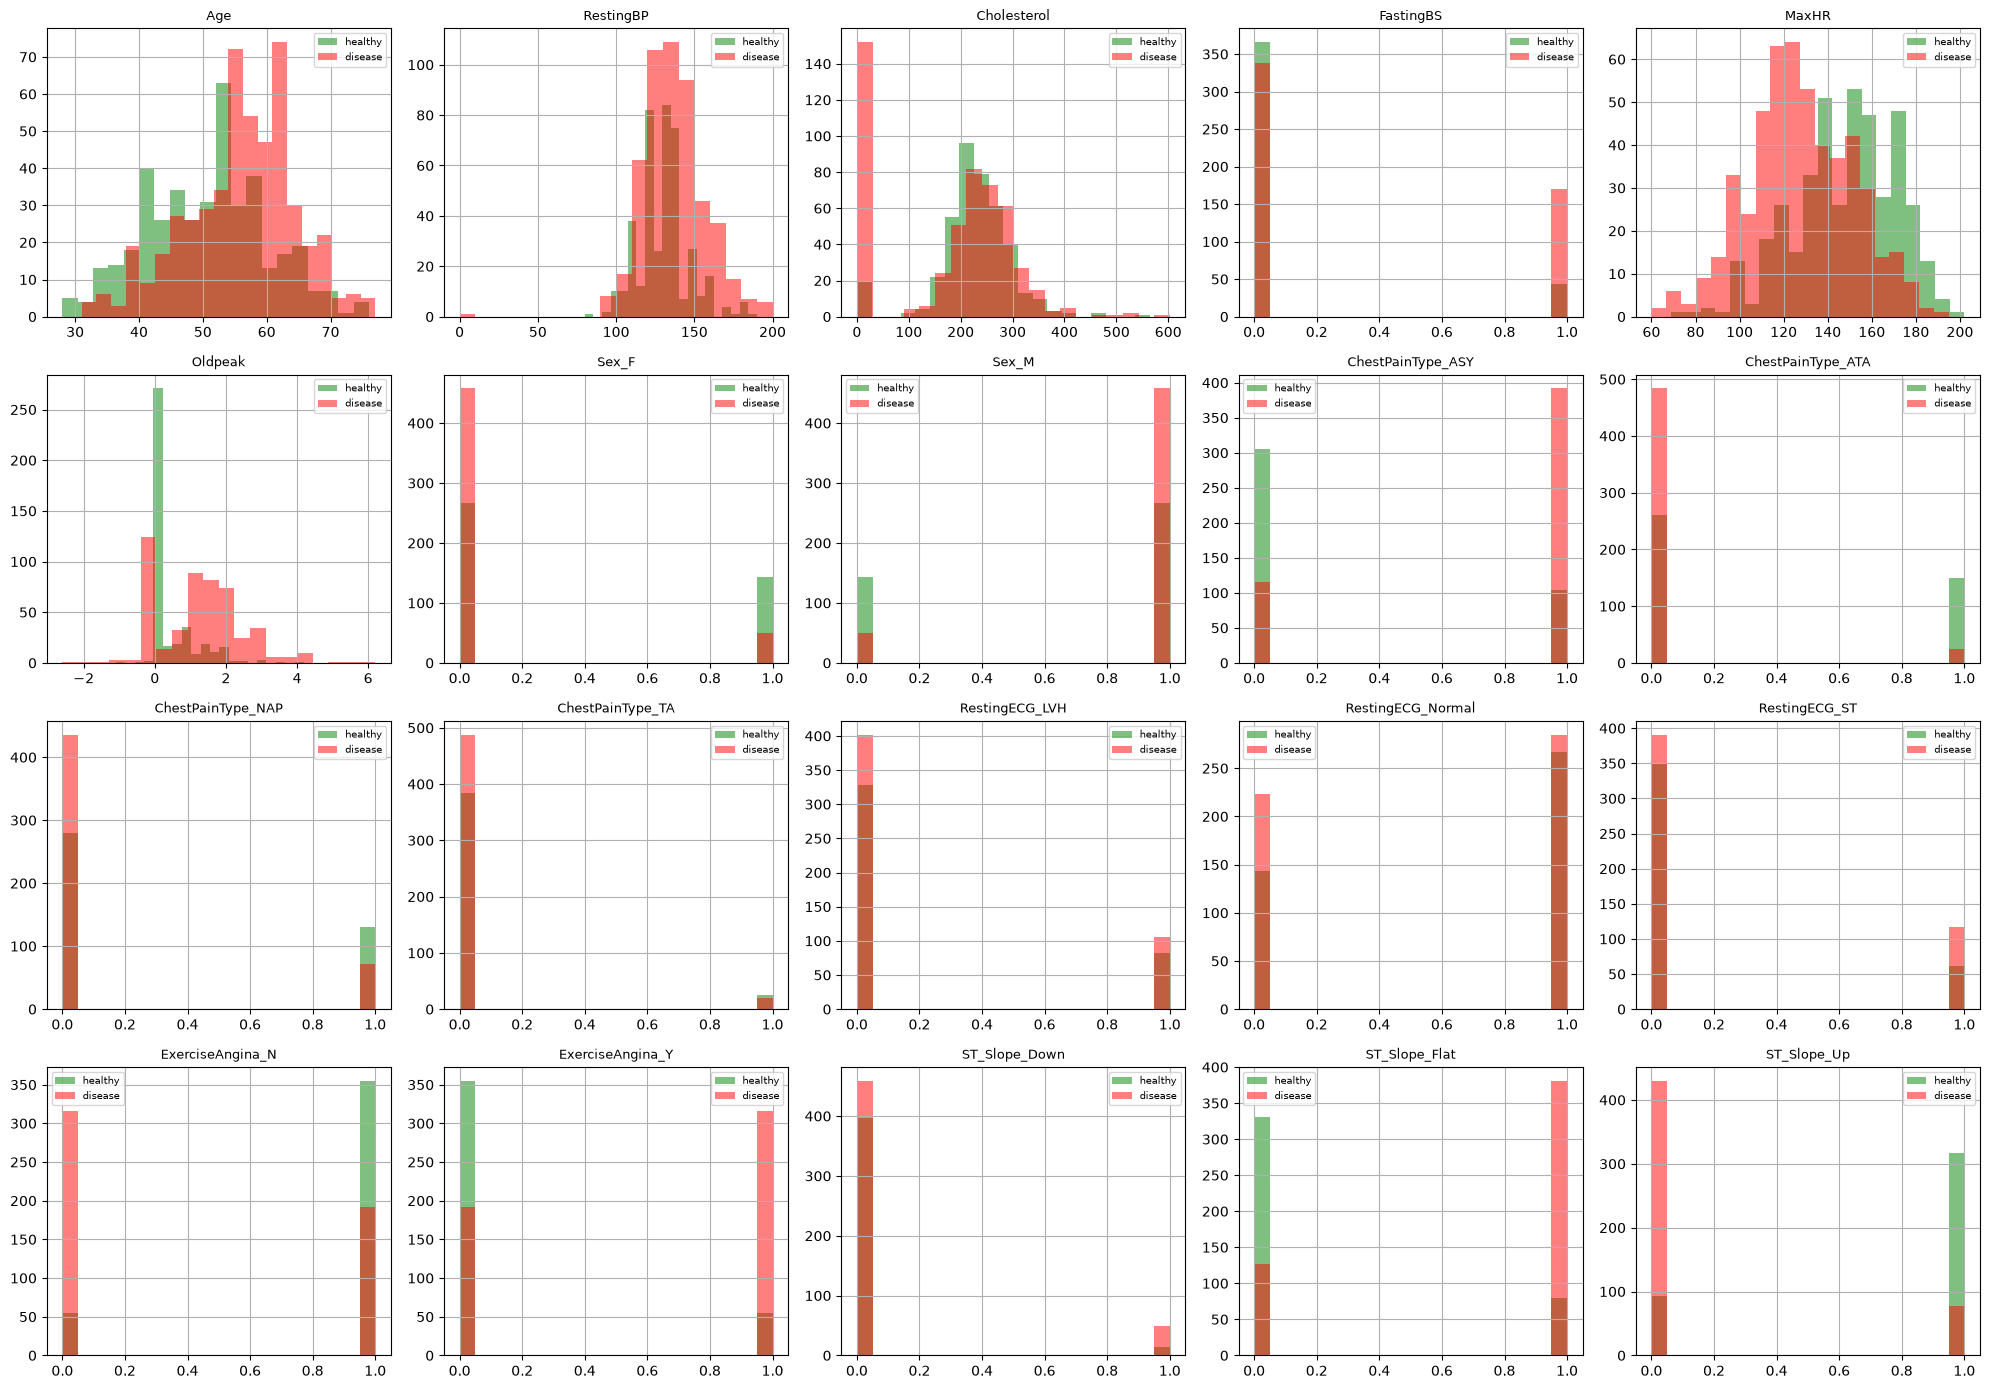

In [15]:
df_plot = X.copy()
df_plot['target'] = y

fig, axes = plt.subplots(4, 5, figsize=(20, 14))
axes = axes.flatten()

colors = {0: 'green', 1: 'red'}
labels = {0: 'healthy', 1: 'disease'}

for i, col in enumerate(X.columns):
    for cls in [0, 1]:
        df_plot[df_plot['target']==cls][col].hist(
            ax=axes[i], alpha=0.5,
            label=labels[cls],
            color=colors[cls],
            bins=20
        )
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.show()

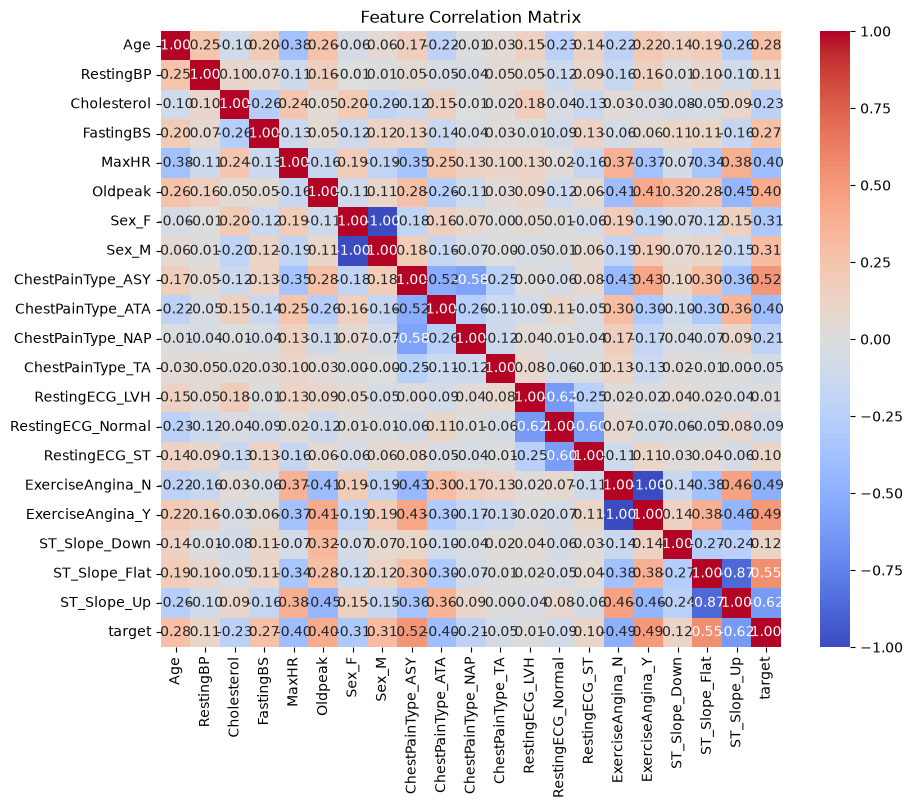

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_plot.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix")
plt.show()

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 734
Test size: 184


In [18]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", round(roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]), 3))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.91      0.83      0.87        82
           1       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184

ROC-AUC: 0.929


In [19]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'  # binary again
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", round(roc_auc_score(y_test,
      xgb.predict_proba(X_test)[:,1]), 3))

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.86      0.87      0.86        82
           1       0.89      0.88      0.89       102

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184

ROC-AUC: 0.929


In [21]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'eval_metric': 'logloss',
        'random_state': 42
    }
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    return roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Best AUC:", round(study.best_value, 3))
print("Best params:", study.best_params)

Best trial: 32. Best value: 0.941176: 100%|██████████| 50/50 [00:02<00:00, 21.92it/s]

Best AUC: 0.941
Best params: {'n_estimators': 71, 'max_depth': 3, 'learning_rate': 0.22478080100305636, 'subsample': 0.7262136709629571, 'colsample_bytree': 0.7744881283700802}


In [22]:
best_xgb = XGBClassifier(**study.best_params, eval_metric='logloss', random_state=42)
best_xgb.fit(X_train, y_train)
y_pred_final = best_xgb.predict(X_test)

print(classification_report(y_test, y_pred_final))
print("ROC-AUC:", round(roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:,1]), 3))

              precision    recall  f1-score   support

           0       0.86      0.89      0.87        82
           1       0.91      0.88      0.90       102

    accuracy                           0.89       184
   macro avg       0.88      0.89      0.88       184
weighted avg       0.89      0.89      0.89       184

ROC-AUC: 0.941


In [ ]:
# import os

# # 1. Define and create the target directory one level up
# model_dir = os.path.normpath("../models/")
# os.makedirs(model_dir, exist_ok=True)

# # 2. Define the complete file path
# model_path = os.path.join(model_dir, "best_xgb_model.json")

# # 3. Save the model from the variable
# best_xgb.save_model(model_path)

# print(f"Model successfully saved to: {model_path}")

Model successfully saved to: ..\models\best_xgb_model.json


In [27]:
import pickle
with open('../models/xgb_model.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)